In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
notebook_path = Path.cwd()

base_path = notebook_path.parent
raw_path = base_path / "data" / "raw"  
plot_path = base_path / "fig" 

In [3]:
# Load your data
abund_mass = pd.read_csv(raw_path / "abundance_biomass.csv" , sep = ";")
sieve = pd.read_csv(raw_path / "sieve.csv", sep = ";")
toc = pd.read_csv(raw_path / "toc.csv", sep = ";")

In [4]:
# Calculate organic matter lost (this is second step)
toc["organic_matter"] = toc["dry_weight"] - toc["ash_weight"]
toc["toc_percent"] = (toc["organic_matter"] / toc["dry_weight"]) * 100 * 0.58

# Group by site to get mean and standard deviation
grouped = toc.groupby(["site","replicate","sample", "month"])['toc_percent'].agg(['mean']).reset_index()

In [5]:
# Preprocessing: Aggregate abundance & biomass per replicate/site/sample
summary = abund_mass.groupby(["site","replicate","sample", "month"]).agg(
    abundance=('prawn_id','count'),
    biomass=('dry_weight','sum'),
    mean_length=('total_length','mean'),
    mean_carapace=('carapace','mean')
).reset_index()

In [6]:
# Merge sediment + TOC
sediment = pd.merge(sieve, grouped, on=["site","replicate","sample", "month"], how="left")

# Merge all into one dataset
merged = pd.merge(summary, sediment, on=["site","replicate","sample", "month"], how="left")

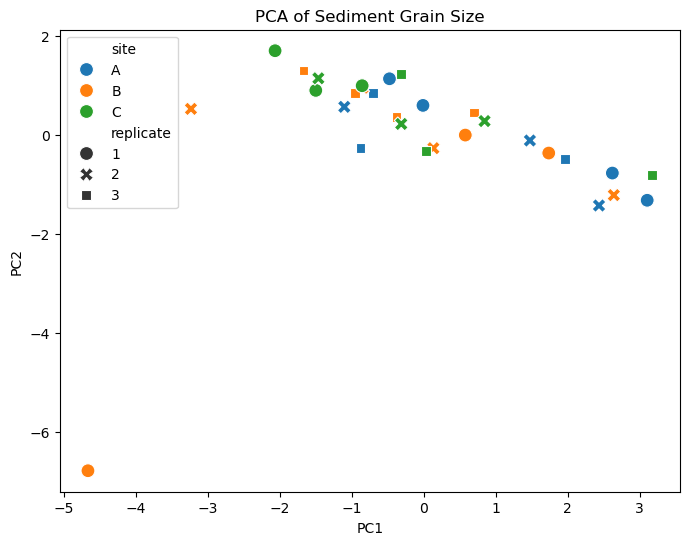

In [7]:
# Select only sieve fractions
grain_cols = ["sieve_2mm","sieve_1mm","sieve_500um","sieve_250um","sieve_125um","sieve_63um","sieve_pan"]

X = merged[grain_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

merged["PC1"] = pca_result[:,0]
merged["PC2"] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="PC1", y="PC2", hue="site", style="replicate", s=100)
plt.title("PCA of Sediment Grain Size")
plt.savefig(plot_path / "PCA.png", dpi=300)
plt.show()

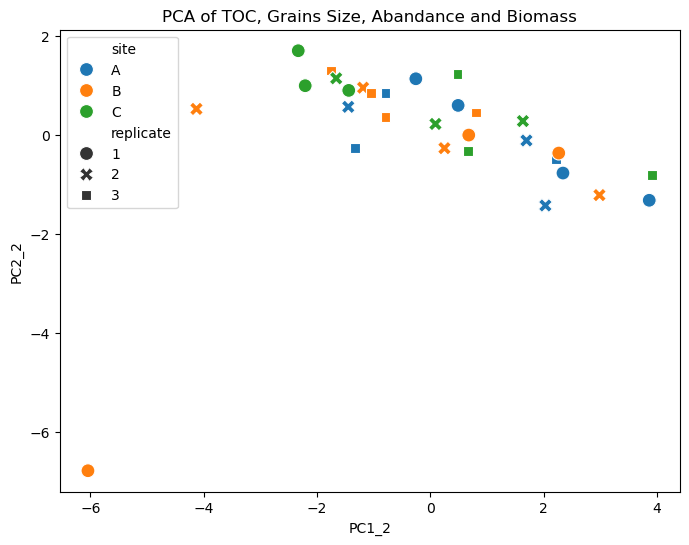

In [8]:
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

pca_result2 = pca.fit_transform(X2_scaled)

merged["PC1_2"] = pca_result2[:,0]
merged["PC2_2"] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="PC1_2", y="PC2_2", hue="site", style="replicate", s=100)
plt.title("PCA of TOC, Grains Size, Abandance and Biomass")
plt.savefig( plot_path / "PCA_2.png", dpi=300)
plt.show()

In [9]:
X = merged[grain_cols].fillna(0)
y = merged[["biomass", "abundance"]]
y_bio = merged[["biomass"]]
y_abun = merged[["abundance"]]

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf_bio = RandomForestRegressor(n_estimators=500, random_state=42)
rf_abun = RandomForestRegressor(n_estimators=500, random_state=42)

rf.fit(X, y)
rf_bio.fit(X, y_bio)
rf_abun.fit(X, y_abun)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_bio = pd.Series(rf_bio.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_abun = pd.Series(rf_abun.feature_importances_, index=X.columns).sort_values(ascending=False)

C:\Users\LENOVO\.conda\envs\zizipho\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\LENOVO\.conda\envs\zizipho\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [10]:
def clean_and_sort_labels(importances):
    """
    Returns two lists:
    - sorted_labels: original column names sorted by sieve size descending, with 'sieve_pan' last
    - sorted_values: corresponding feature importance values in the same order
    """
    label_size_map = {}
    
    for col in importances.index:
        if col == 'sieve_pan':
            label_size_map[col] = -1  # pan will be placed last
        elif 'mm' in col:
            value = float(col.replace('sieve_', '').replace('mm','')) * 1000  # convert mm to um
            label_size_map[col] = value
        elif 'um' in col:
            value = float(col.replace('sieve_', '').replace('um',''))
            label_size_map[col] = value
        else:
            label_size_map[col] = 0  # fallback, just in case

    # Sort by size descending, pan will have -1 so it goes last
    sorted_cols = sorted(label_size_map.keys(), key=lambda x: label_size_map[x], reverse=True)
    
    # Get corresponding importance values
    sorted_values = [importances[col] for col in sorted_cols]
    
    return sorted_cols, sorted_values

In [11]:
x_bio_labels, x_bio_values = clean_and_sort_labels(importances_bio)
x_abun_labels, x_abun_values = clean_and_sort_labels(importances_abun)
x_comb_labels, x_comb_values = clean_and_sort_labels(importances)

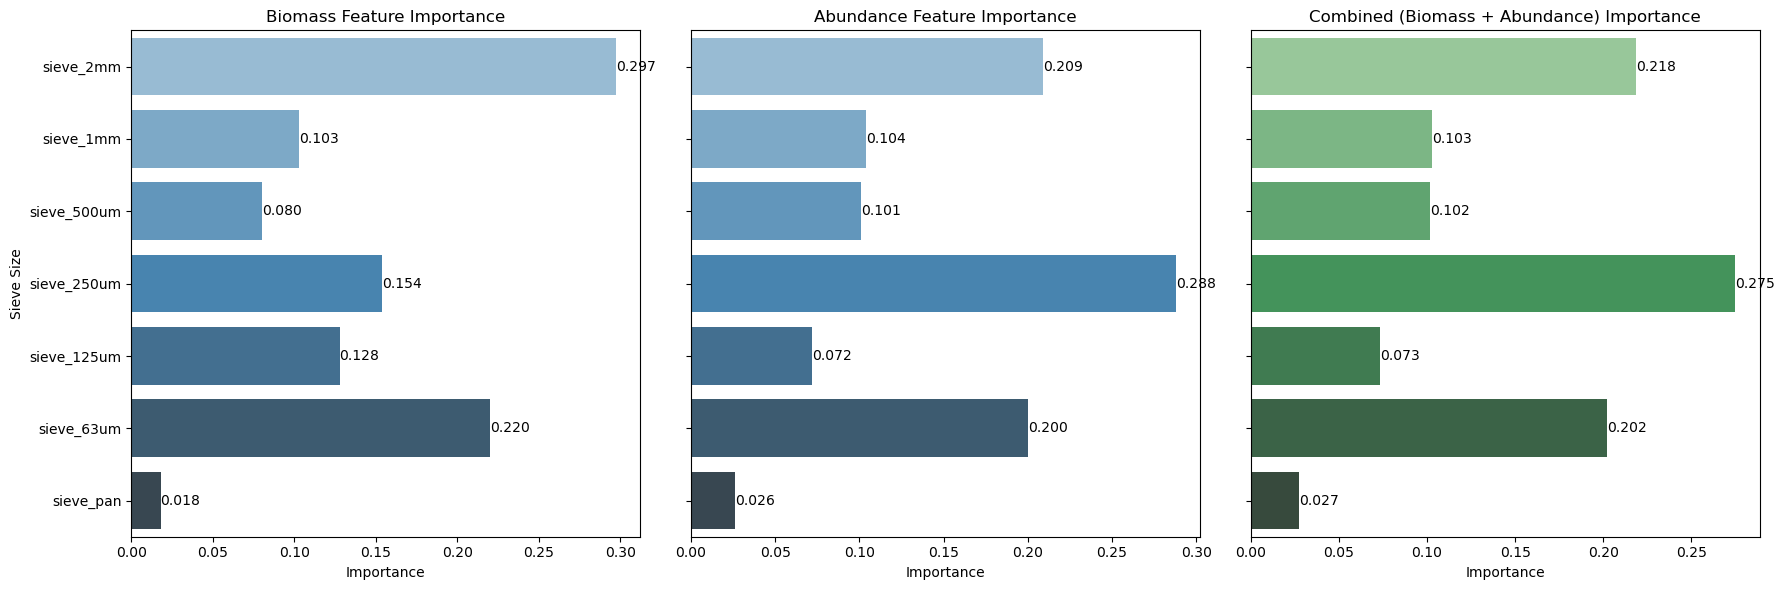

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Biomass
sns.barplot(x=x_bio_values, y=x_bio_labels, ax=axes[0], hue=x_bio_labels, palette="Blues_d")
axes[0].set_title("Biomass Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Sieve Size")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f")

# Abundance
sns.barplot(x=x_abun_values, y=x_abun_labels, ax=axes[1], hue=x_abun_labels, palette="Blues_d")
axes[1].set_title("Abundance Feature Importance")
axes[1].set_xlabel("Importance")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f")


# Combined
sns.barplot(x=x_comb_values, y=x_comb_labels, ax=axes[2], hue=x_comb_labels, palette="Greens_d")
axes[2].set_title("Combined (Biomass + Abundance) Importance")
axes[2].set_xlabel("Importance")
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

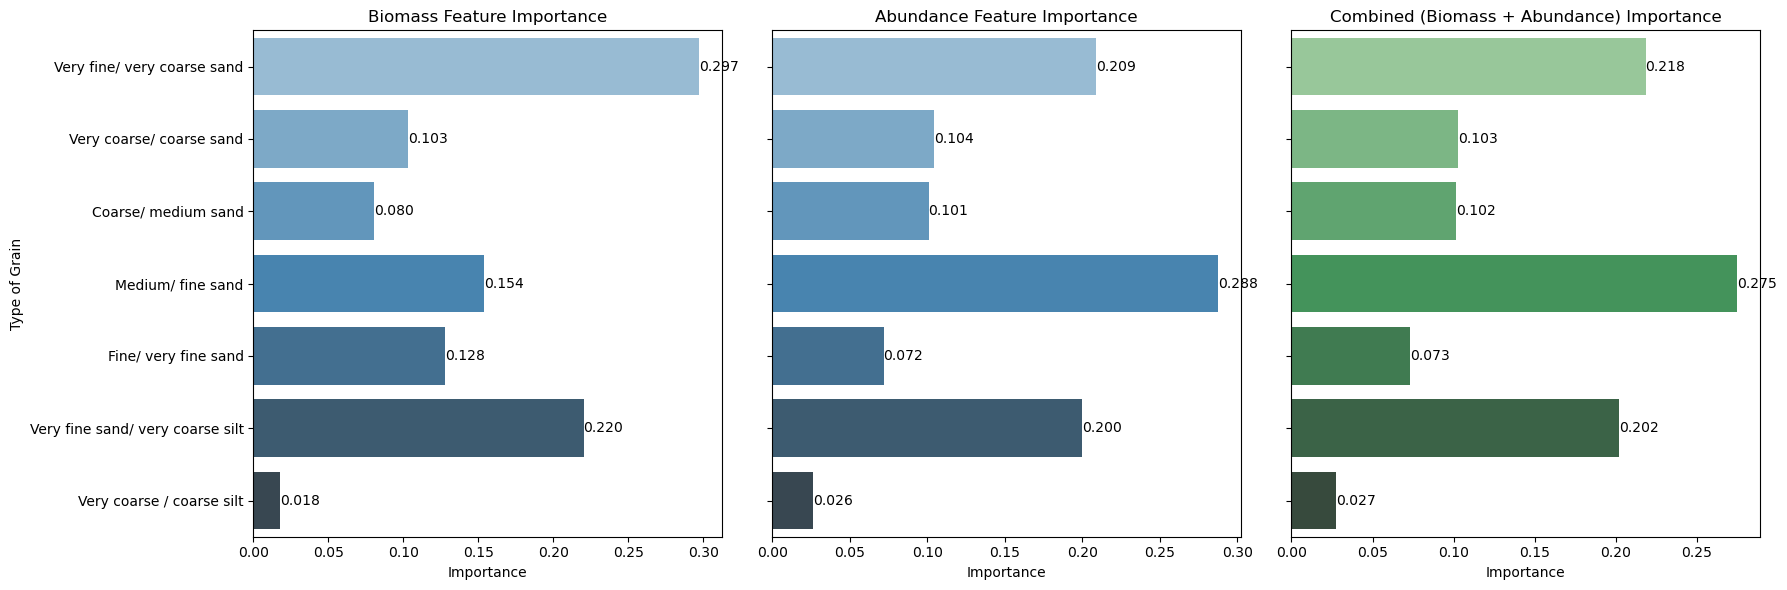

In [13]:
grain_labels = {'sieve_2mm': 'Very fine/ very coarse sand',
                'sieve_1mm': 'Very coarse/ coarse sand',
                'sieve_500um': 'Coarse/ medium sand',
                'sieve_250um': 'Medium/ fine sand',
                'sieve_125um': 'Fine/ very fine sand',
                'sieve_63um': 'Very fine sand/ very coarse silt',
                'sieve_pan': 'Very coarse / coarse silt'}
# Map the labels using your grain_labels dictionary
x_bio_labels_mapped = [grain_labels.get(label, label) for label in x_bio_labels]
x_abun_labels_mapped = [grain_labels.get(label, label) for label in x_abun_labels]
x_comb_labels_mapped = [grain_labels.get(label, label) for label in x_comb_labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Biomass
sns.barplot(x=x_bio_values, y=x_bio_labels_mapped, ax=axes[0], hue=x_bio_labels_mapped, palette="Blues_d", dodge=False)
axes[0].set_title("Biomass Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Type of Grain")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f")

# Abundance
sns.barplot(x=x_abun_values, y=x_abun_labels_mapped, ax=axes[1], hue=x_abun_labels_mapped, palette="Blues_d", dodge=False)
axes[1].set_title("Abundance Feature Importance")
axes[1].set_xlabel("Importance")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f")

# Combined
sns.barplot(x=x_comb_values, y=x_comb_labels_mapped, ax=axes[2], hue=x_comb_labels_mapped, palette="Greens_d", dodge=False)
axes[2].set_title("Combined (Biomass + Abundance) Importance")
axes[2].set_xlabel("Importance")
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.savefig(plot_path / "importance.png", dpi=300)
plt.show()